# 📧 Spam Detection System
### NLP Project — Spring 2025-2026
---

## 1. Import Libraries

In [1]:

!pip install imbalanced-learn -q 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, warnings
from collections import Counter

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt',     quiet=True)
from nltk.corpus import stopwords
from nltk.stem   import PorterStemmer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection         import train_test_split
from sklearn.metrics                 import (accuracy_score,
                                              classification_report,
                                              confusion_matrix,
                                              ConfusionMatrixDisplay)
from sklearn.tree         import DecisionTreeClassifier
from sklearn.ensemble     import RandomForestClassifier
from sklearn.svm          import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes  import MultinomialNB

warnings.filterwarnings('ignore')
np.random.seed(42)
print('All libraries loaded successfully')

All libraries loaded successfully


## 2. Load Dataset

In [2]:

df = pd.read_csv('spam.csv', encoding='latin-1')

df = df[['v1', 'v2']]

df.columns = ['label', 'text']

df['label_num'] = (df['label'] == 'spam').astype(int)

print('Shape :', df.shape)
print('\nColumn names:', df.columns.tolist())
print('\nData types:\n', df.dtypes)
print('\nMissing values:\n', df.isnull().sum())
df.head()

Shape : (5572, 3)

Column names: ['label', 'text', 'label_num']

Data types:
 label        object
text         object
label_num     int32
dtype: object

Missing values:
 label        0
text         0
label_num    0
dtype: int64


,label,text,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


## 3. Exploratory Data Analysis (EDA)

Class distribution:
 label
ham     4825
spam     747
Name: count, dtype: int64


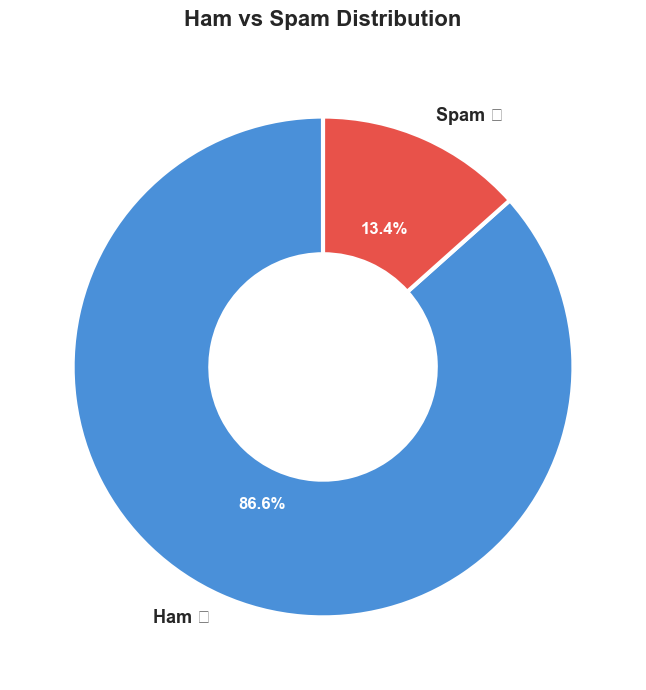

In [3]:

counts = df['label'].value_counts()
print('Class distribution:\n', counts)

plt.style.use('seaborn-v0_8-darkgrid')
fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    counts,
    labels=['Ham ✉', 'Spam 🚫'],
    autopct='%1.1f%%',
    startangle=90,
    colors=['#4A90D9', '#E8524A'],
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=3),
    textprops={'fontsize': 13, 'fontweight': 'bold'}
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_color('white')
    at.set_fontweight('bold')
ax.set_title('Ham vs Spam Distribution', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


## 4. Data Cleaning

In [4]:

rows_before = len(df)

df = df.drop_duplicates().reset_index(drop=True)

print(f'Rows before : {rows_before}')
print(f'Rows removed: {rows_before - len(df)}')
print(f'Rows after  : {len(df)}')

Rows before : 5572
Rows removed: 403
Rows after  : 5169


## 5. Pre-processing

In [5]:

stemmer = PorterStemmer()

stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = re.sub(r'[\r\n\t]+',     ' ',  text)

    text = re.sub(r'\S+@\S+',        '',   text)

    text = re.sub(r'http\S+|www\S+', '',   text)

    text = text.lower()

    text = re.sub(r'[^a-z\s]',        '',   text)

    text = re.sub(r'\s+',             ' ',  text).strip()

    tokens = [stemmer.stem(w) for w in text.split()
              if w not in stop_words and len(w) > 1]

    return ' '.join(tokens)

df['cleaned_text'] = df['text'].apply(preprocess_text)

print(f'Total rows after preprocessing: {len(df)}')
print('\nBefore:\n', df['text'].iloc[0][:200])
print('\nAfter :\n', df['cleaned_text'].iloc[0][:200])

Total rows after preprocessing: 5169

Before:
 Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...

After :
 go jurong point crazi avail bugi great world la buffet cine got amor wat


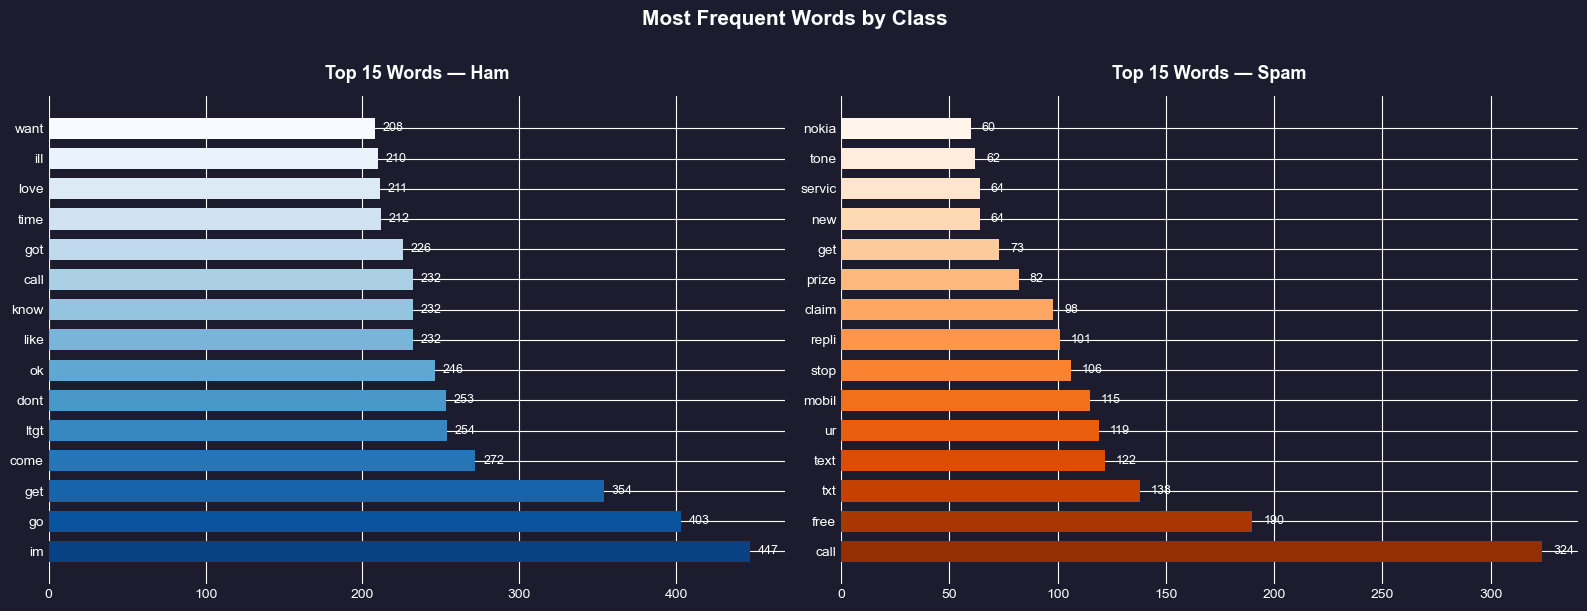

In [6]:

ham_words  = ' '.join(df[df['label_num']==0]['cleaned_text']).split()

spam_words = ' '.join(df[df['label_num']==1]['cleaned_text']).split()

ham_common  = Counter(ham_words).most_common(15)
spam_common = Counter(spam_words).most_common(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#1C1C2E')

ham_colors = plt.cm.Blues_r([i/15 for i in range(1, 16)])
bars = axes[0].barh([w[0] for w in ham_common], [w[1] for w in ham_common],
                    color=ham_colors, edgecolor='none', height=0.7)
axes[0].set_facecolor('#1C1C2E')
axes[0].set_title('Top 15 Words — Ham', fontsize=13, fontweight='bold', color='white', pad=12)
axes[0].tick_params(colors='white')
axes[0].spines[:].set_visible(False)

for bar, (word, val) in zip(bars, ham_common):
    axes[0].text(val + 5, bar.get_y() + bar.get_height()/2,
                 str(val), va='center', color='white', fontsize=9)

spam_colors = plt.cm.Oranges_r([i/15 for i in range(1, 16)])
bars2 = axes[1].barh([w[0] for w in spam_common], [w[1] for w in spam_common],
                     color=spam_colors, edgecolor='none', height=0.7)
axes[1].set_facecolor('#1C1C2E')
axes[1].set_title('Top 15 Words — Spam', fontsize=13, fontweight='bold', color='white', pad=12)
axes[1].tick_params(colors='white')
axes[1].spines[:].set_visible(False)

for bar, (word, val) in zip(bars2, spam_common):
    axes[1].text(val + 5, bar.get_y() + bar.get_height()/2,
                 str(val), va='center', color='white', fontsize=9)

plt.suptitle('Most Frequent Words by Class', fontsize=15, fontweight='bold', color='white', y=1.01)
plt.tight_layout()
plt.show()

## 6. Train / Test Split

In [7]:

X_raw = df['cleaned_text']
y     = df['label_num']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.1, random_state=42, stratify=y
)

print(f'Training size : {len(X_train_raw)}')
print(f'Testing  size : {len(X_test_raw)}')
print(f'Train distribution: {Counter(y_train)}')
print(f'Test  distribution: {Counter(y_test)}')


Training size : 4652
Testing  size : 517
Train distribution: Counter({0: 4064, 1: 588})
Test  distribution: Counter({0: 452, 1: 65})


## 7. TF-IDF Vectorization

In [8]:

tfidf = TfidfVectorizer(max_features=15000, ngram_range=(1, 2))

X_train = tfidf.fit_transform(X_train_raw)
X_test  = tfidf.transform(X_test_raw)

print(f'Total features : {X_train.shape[1]}')
print(f'Train samples  : {X_train.shape[0]}')
print(f'Test  samples  : {X_test.shape[0]}')


Total features : 15000
Train samples  : 4652
Test  samples  : 517


## 8. Handle Class Imbalance — SMOTE

In [9]:

from imblearn.over_sampling import SMOTE

def apply_smote(X_train, y_train, random_state=42):
    smote = SMOTE(random_state=random_state)
    X_resampled, y_resampled = smote.fit_resample(X_train, y_train)
    return X_resampled, y_resampled

X_train_bal, y_train_bal = apply_smote(X_train, y_train)

print(f'Before SMOTE: {Counter(y_train)}')
print(f'After  SMOTE: {Counter(y_train_bal)}')


Before SMOTE: Counter({0: 4064, 1: 588})
After  SMOTE: Counter({0: 4064, 1: 4064})


## 9. Model Training & Evaluation

In [10]:

trained_models = {}
all_results    = []
print('=' * 55)

In [11]:

lr = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
trained_models['Logistic Regression'] = lr

tr_acc = accuracy_score(y_train, lr.predict(X_train))
te_acc = accuracy_score(y_test,  lr.predict(X_test))
gap    = tr_acc - te_acc

all_results.append({'Model': 'Logistic Regression', 'Train Accuracy': tr_acc,
                    'Test Accuracy': te_acc, 'Gap': gap,
                    'Overfitting?': 'Yes' if gap > 0.05 else 'No'})

print(f'\nLogistic Regression')
print(f'  Train Accuracy : {tr_acc:.4f}')
print(f'  Test  Accuracy : {te_acc:.4f}')
print(f'  Gap            : {gap:.4f}  ' + ('Overfit!' if gap > 0.05 else 'OK'))
print(classification_report(y_test, lr.predict(X_test), target_names=['Ham','Spam']))
print('=' * 55)


Logistic Regression
  Train Accuracy : 0.9635
  Test  Accuracy : 0.9632
  Gap            : 0.0002  OK
              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       452
        Spam       0.98      0.72      0.83        65

    accuracy                           0.96       517
   macro avg       0.97      0.86      0.91       517
weighted avg       0.96      0.96      0.96       517



In [12]:

rf = RandomForestClassifier(n_estimators=100, max_depth=20, min_samples_split=5,
                            min_samples_leaf=2, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
trained_models['Random Forest'] = rf

tr_acc = accuracy_score(y_train, rf.predict(X_train))
te_acc = accuracy_score(y_test,  rf.predict(X_test))
gap    = tr_acc - te_acc

all_results.append({'Model': 'Random Forest', 'Train Accuracy': tr_acc,
                    'Test Accuracy': te_acc, 'Gap': gap,
                    'Overfitting?': 'Yes' if gap > 0.05 else 'No'})

print(f'\nRandom Forest')
print(f'  Train Accuracy : {tr_acc:.4f}')
print(f'  Test  Accuracy : {te_acc:.4f}')
print(f'  Gap            : {gap:.4f}  ' + ('Overfit!' if gap > 0.05 else 'OK'))
print(classification_report(y_test, rf.predict(X_test), target_names=['Ham','Spam']))
print('=' * 55)


Random Forest
  Train Accuracy : 0.9340
  Test  Accuracy : 0.9381
  Gap            : -0.0041  OK
              precision    recall  f1-score   support

         Ham       0.93      1.00      0.97       452
        Spam       1.00      0.51      0.67        65

    accuracy                           0.94       517
   macro avg       0.97      0.75      0.82       517
weighted avg       0.94      0.94      0.93       517



In [13]:

svm = SVC(kernel='linear', class_weight='balanced', probability=True, random_state=42)
svm.fit(X_train, y_train)
trained_models['SVM'] = svm

tr_acc = accuracy_score(y_train, svm.predict(X_train))
te_acc = accuracy_score(y_test,  svm.predict(X_test))
gap    = tr_acc - te_acc

all_results.append({'Model': 'SVM', 'Train Accuracy': tr_acc,
                    'Test Accuracy': te_acc, 'Gap': gap,
                    'Overfitting?': 'Yes' if gap > 0.05 else 'No'})

print(f'\nSVM')
print(f'  Train Accuracy : {tr_acc:.4f}')
print(f'  Test  Accuracy : {te_acc:.4f}')
print(f'  Gap            : {gap:.4f}  ' + ('Overfit!' if gap > 0.05 else 'OK'))
print(classification_report(y_test, svm.predict(X_test), target_names=['Ham','Spam']))
print('=' * 55)


SVM
  Train Accuracy : 0.9987
  Test  Accuracy : 0.9845
  Gap            : 0.0142  OK
              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99       452
        Spam       0.95      0.92      0.94        65

    accuracy                           0.98       517
   macro avg       0.97      0.96      0.96       517
weighted avg       0.98      0.98      0.98       517



In [14]:

nb = MultinomialNB(alpha=1.0)
nb.fit(X_train, y_train)
trained_models['Naive Bayes'] = nb

tr_acc = accuracy_score(y_train, nb.predict(X_train))
te_acc = accuracy_score(y_test,  nb.predict(X_test))
gap    = tr_acc - te_acc

all_results.append({'Model': 'Naive Bayes', 'Train Accuracy': tr_acc,
                    'Test Accuracy': te_acc, 'Gap': gap,
                    'Overfitting?': 'Yes' if gap > 0.05 else 'No'})

print(f'\nNaive Bayes')
print(f'  Train Accuracy : {tr_acc:.4f}')
print(f'  Test  Accuracy : {te_acc:.4f}')
print(f'  Gap            : {gap:.4f}  ' + ('Overfit!' if gap > 0.05 else 'OK'))
print(classification_report(y_test, nb.predict(X_test), target_names=['Ham','Spam']))
print('=' * 55)


Naive Bayes
  Train Accuracy : 0.9740
  Test  Accuracy : 0.9691
  Gap            : 0.0049  OK
              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       452
        Spam       1.00      0.75      0.86        65

    accuracy                           0.97       517
   macro avg       0.98      0.88      0.92       517
weighted avg       0.97      0.97      0.97       517



In [15]:

dt = DecisionTreeClassifier(max_depth=20, min_samples_split=5,
                             min_samples_leaf=2, random_state=42)
dt.fit(X_train, y_train)
trained_models['Decision Tree'] = dt

tr_acc = accuracy_score(y_train, dt.predict(X_train))
te_acc = accuracy_score(y_test,  dt.predict(X_test))
gap    = tr_acc - te_acc

all_results.append({'Model': 'Decision Tree', 'Train Accuracy': tr_acc,
                    'Test Accuracy': te_acc, 'Gap': gap,
                    'Overfitting?': 'Yes' if gap > 0.05 else 'No'})

print(f'\nDecision Tree')
print(f'  Train Accuracy : {tr_acc:.4f}')
print(f'  Test  Accuracy : {te_acc:.4f}')
print(f'  Gap            : {gap:.4f}  ' + ('Overfit!' if gap > 0.05 else 'OK'))
print(classification_report(y_test, dt.predict(X_test), target_names=['Ham','Spam']))
print('=' * 55)


Decision Tree
  Train Accuracy : 0.9837
  Test  Accuracy : 0.9516
  Gap            : 0.0320  OK
              precision    recall  f1-score   support

         Ham       0.96      0.99      0.97       452
        Spam       0.90      0.69      0.78        65

    accuracy                           0.95       517
   macro avg       0.93      0.84      0.88       517
weighted avg       0.95      0.95      0.95       517



In [16]:
import joblib

joblib.dump(tfidf, 'tfidf.pkl')
joblib.dump(trained_models, 'models.pkl')
print('Saved!')

Saved!


## 10. Models Comparison

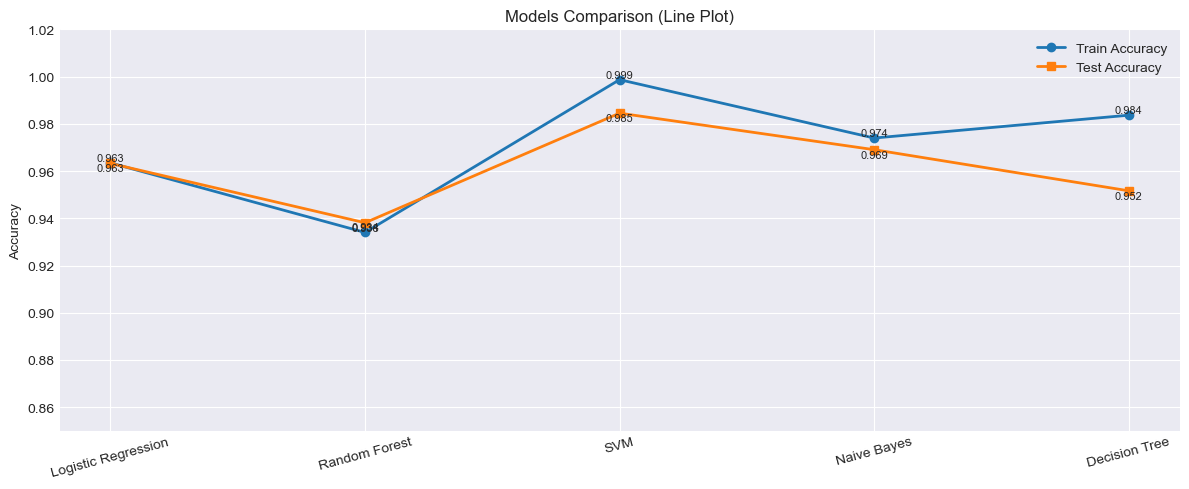

In [17]:

results_df = pd.DataFrame(all_results).set_index('Model')

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(results_df.index, results_df['Train Accuracy'],
        marker='o', linewidth=2, label='Train Accuracy')

ax.plot(results_df.index, results_df['Test Accuracy'],
        marker='s', linewidth=2, label='Test Accuracy')

ax.set_ylim(0.85, 1.02)
ax.set_ylabel('Accuracy')
ax.set_title('Models Comparison (Line Plot)')
ax.legend()

plt.xticks(rotation=15)

for i, v in enumerate(results_df['Train Accuracy']):
    ax.text(i, v, f"{v:.3f}", ha='center', va='bottom', fontsize=8)

for i, v in enumerate(results_df['Test Accuracy']):
    ax.text(i, v, f"{v:.3f}", ha='center', va='top', fontsize=8)

plt.tight_layout()
plt.show()

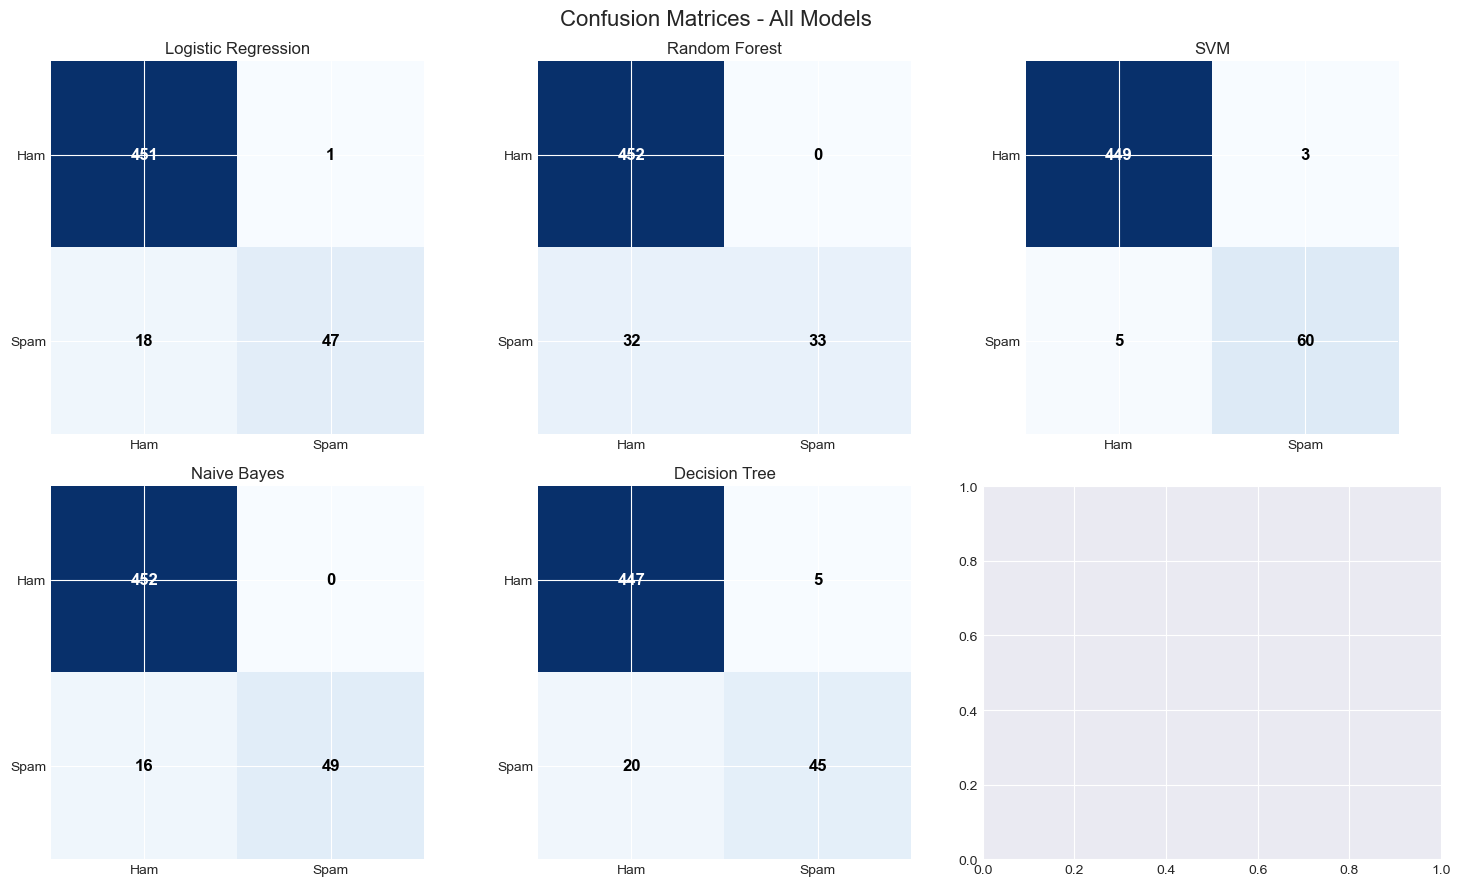

In [18]:

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, (name, model) in enumerate(trained_models.items()):
    cm = confusion_matrix(y_test, model.predict(X_test))

    im = axes[i].imshow(cm, cmap='Blues')

    for x in range(cm.shape[0]):
        for y in range(cm.shape[1]):
            color = "white" if cm[x, y] > cm.max()/2 else "black"
            axes[i].text(y, x, cm[x, y],
                         ha="center", va="center",
                         color=color, fontsize=12, fontweight='bold')

    axes[i].set_xticks([0, 1])
    axes[i].set_yticks([0, 1])
    axes[i].set_xticklabels(['Ham', 'Spam'])
    axes[i].set_yticklabels(['Ham', 'Spam'])
    axes[i].set_title(name)

plt.suptitle('Confusion Matrices - All Models', fontsize=16)
plt.tight_layout()
plt.show()

## 11. Graphical User Interface (GUI)

In [19]:
import tkinter as tk
from tkinter import font as tkfont

# ================= COLORS =================
BG = "#0f172a"
PANEL = "#1e293b"
BTN_RUN = "#22c55e"
BTN_CLR = "#ef4444"
FG = "#f8fafc"

IDLE_BG = "#334155"
SPAM_BG = "#dc2626"
HAM_BG = "#16a34a"

MODEL_LIST = list(trained_models.items())

# ================= FUNCTIONS =================

def run_prediction():
    raw = msg_box.get("1.0", tk.END).strip()

    if not raw:
        return

    cleaned = preprocess_text(raw)
    vec = tfidf.transform([cleaned])

    for i, (_, model) in enumerate(MODEL_LIST):

        pred = model.predict(vec)[0]

        if pred == 1:
            res_vars[i].set("⚠️ SPAM")
            res_lbls[i].config(bg=SPAM_BG, fg="white")
        else:
            res_vars[i].set("✅ HAM")
            res_lbls[i].config(bg=HAM_BG, fg="white")


def clear_all():
    msg_box.delete("1.0", tk.END)

    for i in range(len(MODEL_LIST)):
        res_vars[i].set("")
        res_lbls[i].config(bg=IDLE_BG, fg=FG)


# ================= WINDOW =================

root = tk.Tk()
root.title("Spam Detection System")
root.geometry("900x800")
root.resizable(True, True)
root.configure(bg=BG)

# ================= FONTS =================

t_title = tkfont.Font(family="Segoe UI", size=22, weight="bold")
t_sub = tkfont.Font(family="Segoe UI", size=11)
t_label = tkfont.Font(family="Segoe UI", size=11)
t_result = tkfont.Font(family="Segoe UI", size=11, weight="bold")
t_btn = tkfont.Font(family="Segoe UI", size=11, weight="bold")

# ================= HEADER =================

tk.Label(
    root,
    text="📧 Spam Detection System",
    font=t_title,
    bg=BG,
    fg="#38bdf8"
).pack(pady=(20, 5))

tk.Label(
    root,
    text="Machine Learning & NLP Project",
    font=t_sub,
    bg=BG,
    fg="#94a3b8"
).pack(pady=(0, 20))

# ================= INPUT PANEL =================

in_panel = tk.Frame(root, bg=PANEL)
in_panel.pack(fill="x", padx=30, pady=10)

tk.Label(
    in_panel,
    text="Enter Message:",
    font=t_label,
    bg=PANEL,
    fg=FG
).pack(anchor="w", padx=15, pady=(12, 5))

msg_box = tk.Text(
    in_panel,
    height=7,
    font=("Segoe UI", 11),
    bg="#020617",
    fg="white",
    insertbackground="white",
    relief="flat",
    padx=10,
    pady=10
)

msg_box.pack(fill="x", padx=15, pady=(0, 15))

# ================= BUTTONS =================

btn_row = tk.Frame(root, bg=BG)
btn_row.pack(pady=15)

tk.Button(
    btn_row,
    text="Process",
    font=t_btn,
    bg=BTN_RUN,
    fg="white",
    relief="flat",
    padx=25,
    pady=10,
    command=run_prediction
).pack(side="left", padx=10)

tk.Button(
    btn_row,
    text="Clear",
    font=t_btn,
    bg=BTN_CLR,
    fg="white",
    relief="flat",
    padx=25,
    pady=10,
    command=clear_all
).pack(side="left", padx=10)

# ================= RESULTS PANEL =================

res_panel = tk.Frame(root, bg=PANEL)
res_panel.pack(fill="both", expand=True, padx=30, pady=15)

tk.Label(
    res_panel,
    text="Classification Results",
    font=("Segoe UI", 13, "bold"),
    bg=PANEL,
    fg="#38bdf8"
).grid(row=0, column=0, columnspan=2, padx=15, pady=15)

res_vars = []
res_lbls = []

for i, (name, _) in enumerate(MODEL_LIST):

    tk.Label(
        res_panel,
        text=name,
        font=t_label,
        bg=PANEL,
        fg=FG,
        width=35,
        anchor="w"
    ).grid(row=i + 1, column=0, padx=20, pady=8, sticky="w")

    var = tk.StringVar()

    lbl = tk.Label(
        res_panel,
        textvariable=var,
        font=t_result,
        bg=IDLE_BG,
        fg=FG,
        width=15,
        pady=5
    )

    lbl.grid(row=i + 1, column=1, padx=20, pady=8)

    res_vars.append(var)
    res_lbls.append(lbl)

root.mainloop()